In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\ANUSREE C R\Downloads\archive (2)\Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.loc[df["Heart Disease"]=='Presence','Heart Disease']
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## Label encoding

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# create encoder
heart_encoder = LabelEncoder()

# encode column
df["Heart Disease"] = heart_encoder.fit_transform(df["Heart Disease"])

# show mapping
mapping = dict(zip(heart_encoder.classes_, heart_encoder.transform(heart_encoder.classes_)))
print("Mapping:", mapping)

# save encoder
joblib.dump(heart_encoder, "heart_encoder.pkl")

# check result
print(df.head())

Mapping: {'Absence': np.int64(0), 'Presence': np.int64(1)}
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium  Heart Disease  
0                        3         3              1  
1                    

In [6]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [7]:
df.shape

(270, 14)

## Histogram

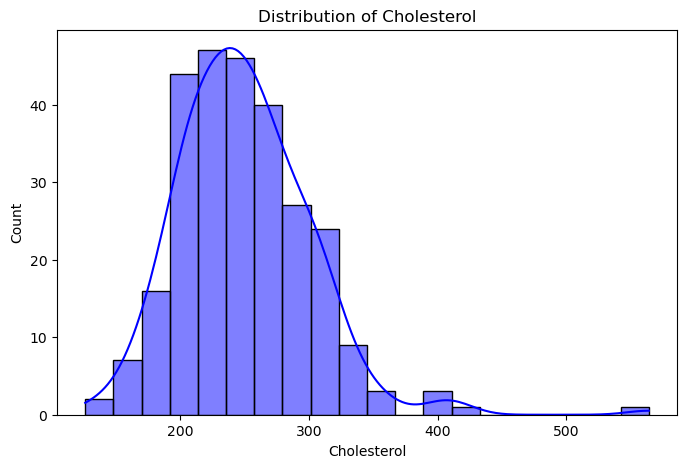

In [9]:
# Simple histogram for Cholesterol
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol'], bins=20, kde=True, color='blue')
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

## Boxplot

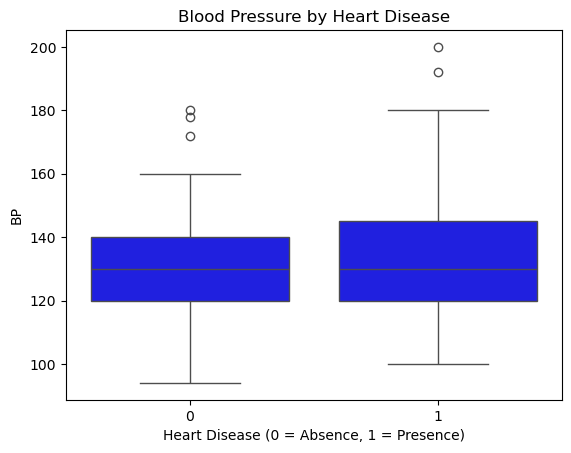

In [8]:
sns.boxplot(x='Heart Disease', y='BP', data=df, color='blue')
plt.title("Blood Pressure by Heart Disease")
plt.xlabel("Heart Disease (0 = Absence, 1 = Presence)")
plt.ylabel("BP")
plt.show()

## Count Plot

C:\Users\ANUSREE C R\AppData\Local\Temp\ipykernel_25860\2539526577.py:2: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='Heart Disease', data=df,hue='Heart Disease',dodge=False, palette=['purple'],legend=False)


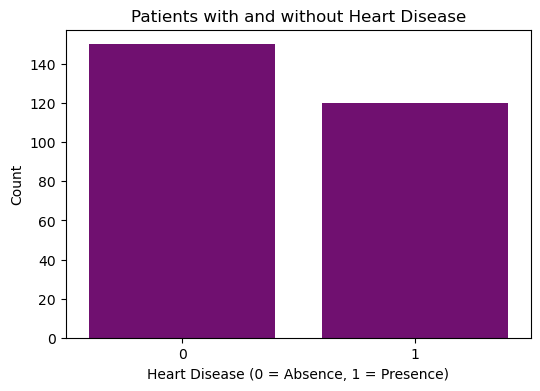

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Heart Disease', data=df,hue='Heart Disease',dodge=False, palette=['purple'],legend=False)
plt.title("Patients with and without Heart Disease")
plt.xlabel("Heart Disease (0 = Absence, 1 = Presence)")
plt.ylabel("Count")
plt.show()

## Heat Map

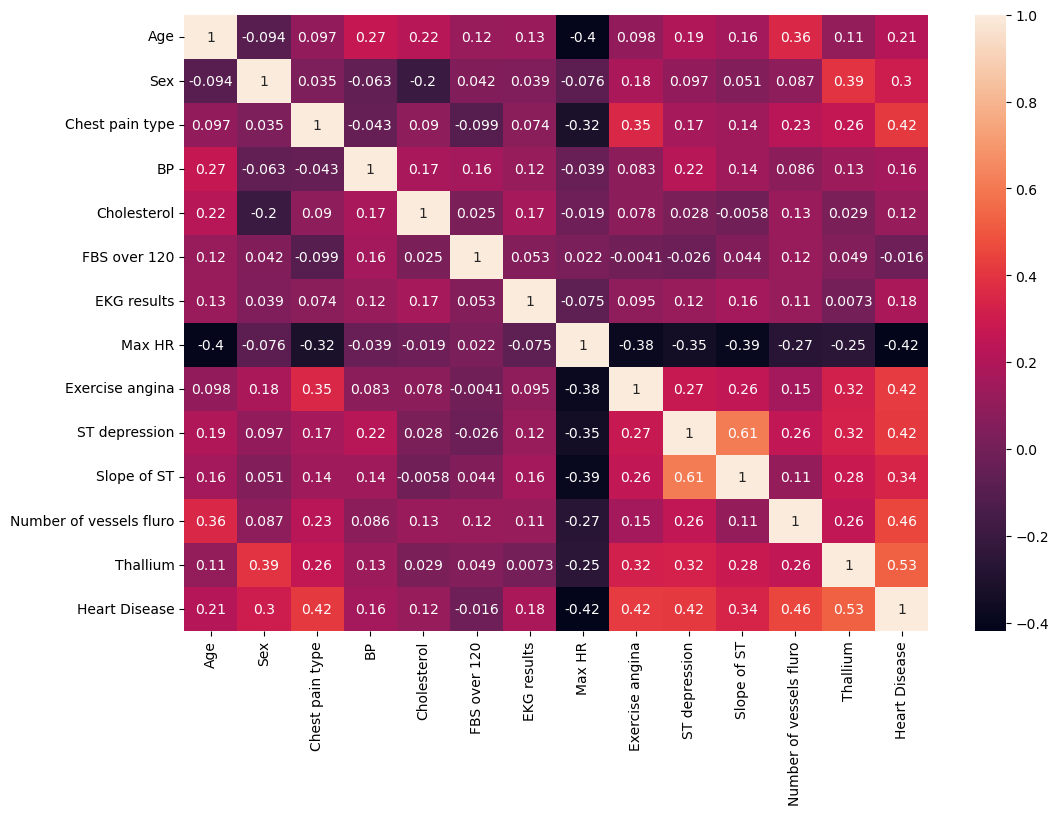

In [8]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

In [9]:
df.drop("FBS over 120", axis =1, inplace= True)

In [10]:
X= df.drop("Heart Disease", axis=1) # feature class

In [11]:
X.head()

,Age,Sex,Chest pain type,BP,Cholesterol,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,2,109,0,2.4,2,3,3
1,67,0,3,115,564,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,105,1,0.2,2,1,7
4,74,0,2,120,269,2,121,1,0.2,1,1,3


In [12]:
y= df["Heart Disease"]# labels class

In [13]:
y.tail()

265    0
266    0
267    0
268    0
269    1
Name: Heart Disease, dtype: int64

## Test and Train

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test data
    random_state=24)    # ensures same split every tim )   

In [16]:
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
249,60,1,4,145,282,2,142,1,2.8,2,2,7
112,60,0,4,158,305,2,161,0,0.0,1,0,3
87,59,1,1,178,270,2,145,0,4.2,3,0,7
124,54,1,3,125,273,2,152,0,0.5,3,1,3
82,58,1,4,150,270,2,111,1,0.8,1,0,7


In [17]:
y_train.tail()

207    0
123    0
129    1
145    1
192    0
Name: Heart Disease, dtype: int64

# Models

In [18]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression

In [19]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7777777777777778


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[27  4]
 [ 8 15]]


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82        31
           1       0.79      0.65      0.71        23

    accuracy                           0.78        54
   macro avg       0.78      0.76      0.77        54
weighted avg       0.78      0.78      0.77        54



## GaussianNB

In [25]:
from sklearn.naive_bayes import GaussianNB

model_G = GaussianNB()
model_G.fit(X_train, y_train)

y_pred = model_G.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7777777777777778


In [27]:
from sklearn.neighbors import KNeighborsClassifier

model_K  = KNeighborsClassifier(n_neighbors=5)
model_K.fit(X_train, y_train)

y_pred = model_K.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.6111111111111112


In [28]:
from sklearn.tree import DecisionTreeClassifier

model_D = DecisionTreeClassifier(random_state=42)
model_D.fit(X_train, y_train)

y_pred = model_D.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7407407407407407


In [29]:
from sklearn.ensemble import RandomForestClassifier

model_R = RandomForestClassifier(n_estimators=100, random_state=42)
model_R.fit(X_train, y_train)

y_pred = model_R.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7777777777777778


In [30]:
from sklearn.svm import SVC

model_SVC = SVC(kernel='rbf')
model_SVC.fit(X_train, y_train)

y_pred = model_SVC.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6851851851851852


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model_Grad = GradientBoostingClassifier()
model_Grad.fit(X_train, y_train)

y_pred = model_Grad.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8148148148148148


In [33]:
import joblib
joblib.dump(model_Grad,'best_model_heart.pkl')

['best_model_heart.pkl']